# **Libraries & Setup**

In [27]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import plotly.express as px # generates an interactive visual
from statsmodels.tsa.stattools import adfuller # will use for stationarity test
from statsmodels.tsa.seasonal import seasonal_decompose # Separates the series into layers

from scipy.stats import boxcox # scipy scientific computing library,
# Variance -> how much the series oscillates. If peaks and troughs grow over time, the variance is unstable
# boxcox automatically finds the best lambda (λ) to
# stabilize the series variance, compressing oscillations that grow with the trend. λ≈0 is equivalent to the logarithm.

from statsmodels.graphics.tsaplots import plot_acf # Library to check autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf # Library to check partial autocorrelation
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [28]:
df = pd.read_csv('airpassengers_dataset.csv', delimiter=',', header='infer')

In [29]:
df.head()

,date,passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


# **Plotting the Graph**

In [30]:
def plotting(title, data, x, y, x_label, y_label): # function to facilitate plotting
   fig = px.line(data, x=data[x], y= data[y], labels= {x: x_label, y: y_label, }) # px.line -> line chart for Time Series, Labels are the axis labels

   fig.update_layout(template='simple_white', font=dict(size=18), # template = Clean visual, graph font,
   title_text= title, width = 650, title_x = 0.5, height = 400 ) # title, width, horizontal position of the title, 0 = left, 1 = right, 0.5 = centered, height


   fig.show()

In [31]:
#Dont forget to make sure that your date is in datetime format
df['date'] = pd.to_datetime(df['date'])

In [32]:
#Plotting to check how they are
plotting('Airport Passengers',  df, 'date', 'passengers', 'Date', 'Passengers')

NON-STATIONARY AUTOCORRELATION

<Figure size 1000x500 with 0 Axes>

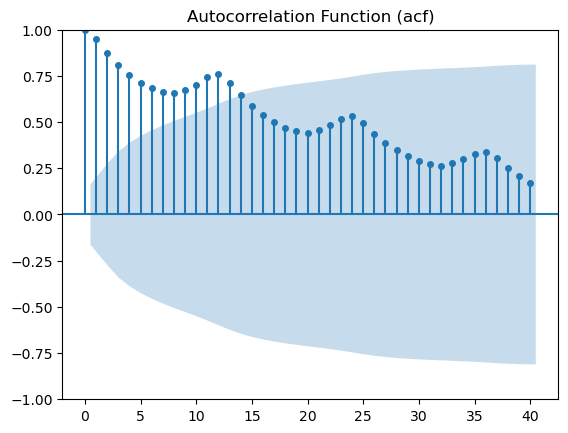

In [33]:
passageiro = df['passengers']
plt.figure(figsize=(10, 5))
plot_acf(passageiro, lags=40, markersize=4) #lags=40 -> covers ~3 annual seasonal cycles (3 × 12 months = 36, rounded to 40), markersize = size of the dots on top of each bar of the graph
plt.title('Autocorrelation Function (acf)')
plt.show()

# **Understanding the series at hand through decomposition**

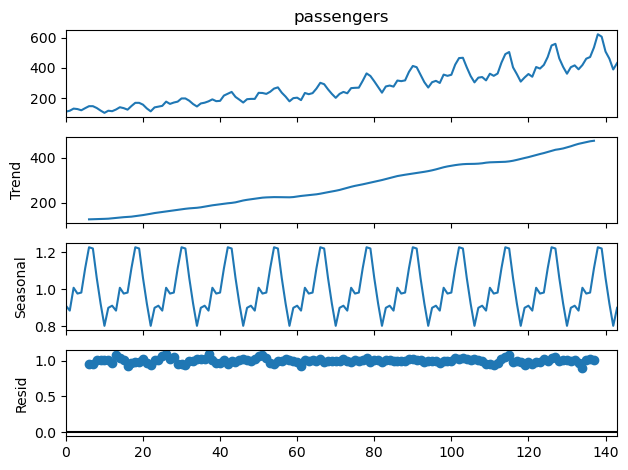

In [34]:
#To see the decomposition of this series
#We have two ways to do this: Multiplicative and Additive
#Additive -> Series has a fixed growth, e.g., "Every year ice cream purchases increase by 10 Reais"
#Multiplicative -> Series has varied growth, without a fixed number.
#It is worth noting that it is possible to transform a multiplicative series into an additive one. Transform the series with log or boxcox and then apply the additive model.

#MULTIPLICATIVE
decomp_mult = seasonal_decompose(df['passengers'], model='multiplicative', period=12)

#if I remove the plt.show() below, the same decomposition will be displayed twice.

decomp_mult.plot() # generates the figure
plt.show() # displays and clears — Jupyter no longer finds anything to duplicate

It's possible to perceive a clear trend that continues to increase without drops, clearly non-stationary. In terms of seasonality, we see that it oscillates between 0.8 and 1.2, meaning that in certain months the number of passengers is 20% above or below the trend, and finally, the residual is around 1.0 with small random fluctuations.

# **Stabilizing the Variance with Box-Cox**

In [35]:
df['Pass_box'],      lam =            boxcox(df['passengers'])
#Transformed serie  #best lambda
print(lam)

plotting(title = 'Variance Stabilization using Box-Cox ', data=df, x='date', y='Pass_box', x_label= 'Date', y_label = 'Passengers')

0.14802261727063243


# **Removing Seasonality**

In [36]:
df['sazorm_pass'] = df['Pass_box'].diff(12) #monthly = 12 months
plotting(title = 'Removing Monthly Seasonality', data=df, x='date', y='sazorm_pass', x_label= 'Date', y_label = 'Passengers')

# **Removing Trend**

In [37]:
df['tendrm_pass'] = df['sazorm_pass'].diff(1) #Removal of the previous trend
plotting(title = 'Removing Trend', data=df, x='date', y='tendrm_pass', x_label= 'Date', y_label = 'Passengers')

# **ADF TEST (adfuller) Check for stationarity**

In [38]:
def adf(x): #function to check if it is stationary or not
  result = adfuller(x) #returns two values
  print(f'ADF Statistic: {result[0]}') # 1 - (The more negative the better)
  print(f'P-value: {result[1]}') #2 - If p-value < 0.05, we reject the Null Hypothesis (H0), meaning the series is stationary.
  print(f'Critical Values: ')
  for key, value in result[4].items():
    print(f' {key}: {value:.3f}')

adf(df['tendrm_pass'].dropna()) #due to the removal of monthly seasonality and trend, the first 13 values are null, so we exclude them

ADF Statistic: -4.393872606580145
P-value: 0.000304332604185832
Critical Values: 
 1%: -3.487
 5%: -2.886
 10%: -2.580


# **AUTOCORRELATION (ACF) Stationary**

## *Below, we can conclude:*
## Lags outside the blue band are statistically significant
## lag 0 -> doesn't count, as it's itself
## lag 1  → outside the band → non-seasonal (short term, 1 month ago)
## lag 12 → outside the band → seasonal (12 months = 1 complete annual cycle)
## multiples of 12 (24, 36...) would also be seasonal, but are within the band → irrelevant
## rest → within the band (Blue circle - confidence interval) → irrelevant

<Figure size 1000x500 with 0 Axes>

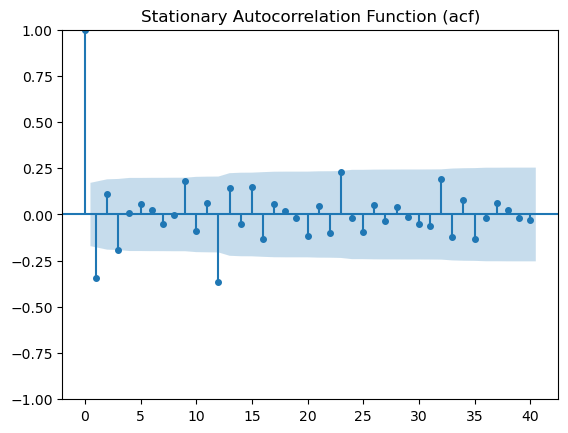

In [39]:
estac = df['tendrm_pass'].dropna()
plt.figure(figsize=(10, 5))
plot_acf(estac, lags=40, markersize=4) #lags=40 → covers ~3 annual seasonal cycles (3 × 12 months = 36, rounded to 40), markersize = size of the dots on top of each bar of the graph
plt.title('Stationary Autocorrelation Function (acf)')
plt.show()

# **PARTIAL AUTOCORRELATION (PACF)**

# ACF (Autocorrelation Function) → measures the TOTAL correlation of the series with itself in the past
# PACF (Partial Autocorrelation Function) → measures the DIRECT correlation, removing the effect of intermediate lags

# Example:
# ACF  → today vs 3 days ago (includes indirect effect of day 1 and 2 in between)
# PACF → today vs 3 days ago (removes the effect of day 1 and 2, pure correlation)

# How to read the graph (applies to both):
# lag 0          → always ignore (correlation of the series with itself)
# OUTSIDE the blue band  → significant lag ✅
# INSIDE the blue band → irrelevant lag
# multiples of 12 (12, 24, 36...) → seasonal
# any other lag  → non-seasonal

<Figure size 1000x400 with 0 Axes>

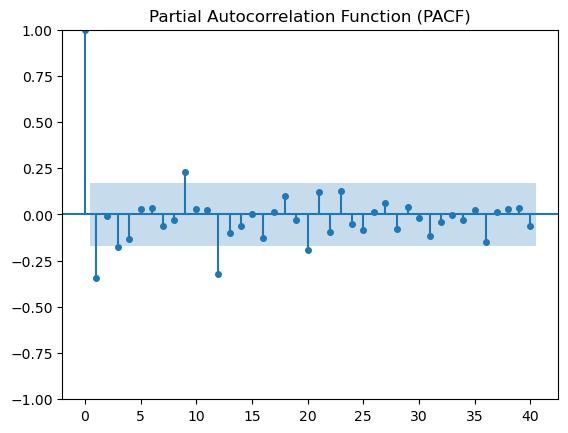

In [40]:
plt.figure(figsize=(10, 4))
plot_pacf(estac, lags=40, markersize=4, method='ywm') # The method defines which mathematical method will be used to calculate the partial autocorrelation; 'ywm' is standard but I specified it to show this option exists.
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

lag 0  → always ignore <br>
lag 1  → clearly outside the band (negative ~-0.35) ✅<br>
lag 3  → slightly outside the band (negative ~-0.15) ⚠️ borderline<br>
lag 9  → clearly outside the band (negative ~-0.30) ✅<br>
lag 12 → clearly outside the band (negative ~-0.30) ✅<br>
lag 20 → slightly outside the band (negative ~-0.20) ⚠️ borderline<br>
rest  → within the band → irrelevant<br>

Do borderlines (lag 3 and lag 20) count?

In practice, borderlines are usually ignored — the risk of unnecessarily complicating the model outweighs the benefit.

Lag 9 is intriguing.

In the real world, the influence of the past on the present tends to be gradual and consecutive:
lag 1 influences → lag 2 influences → lag 3 influences...
If a significant lag 9 suddenly appears, but lags 7, 8, and 10 are not, this is strange.

"the number of passengers today is directly influenced by that of 9 months ago"
This is difficult to justify contextually and unnecessarily complicates the model.

  # **Error Metrics**



# MAE — Mean Absolute Error

MAE = mean of absolute errors

|error| → removes negative sign
mean  → averages all errors

Forecasts:  100, 200, 300 <br>
Actuals:      120, 180, 310 <br>
Errors:      -20, +20, -10 <br>
|Errors|:     20,  20,  10 <br>
MAE = (20+20+10) / 3 = 16.6

**Interpretation:** on average, the model errs by 16.6 passengers per forecast.

**Advantage:** easy to interpret, in the same unit as the data. <br>
**Disadvantage**: treats large and small errors equally.

# MSE — Mean Squared Error

MSE = mean of squared errors

error²  → squares (amplifies large errors)
mean  → averages

Errors:   -20,  +20,  -10 <br>
Errors²:   400,  400,  100 <br>
MSE = (400+400+100) / 3 = 300

Interpretation: difficult to interpret directly (unit is passengers²). <br>
**Advantage**: punishes large errors much more than small errors.<br>
**Disadvantage**: unit makes no practical sense.

# RMSE — Root Mean Squared Error

RMSE = square root of MSE <br>
→ returns to the original unit of the data

MSE = 300
RMSE = √300 = 17.3

Interpretation: similar to MAE, but large errors weigh more. <br>

MAE  = 16.6 → treats all errors equally <br>
RMSE = 17.3 → penalizes large errors more <br>

**Advantage:** same unit as data + sensitive to large errors.<br>

**Disadvantage**: more sensitive to outliers.

# MAPE — Mean Absolute Percentage Error

MAPE = mean of absolute percentage errors

error%  = |error| / actual value × 100

Errors:  20,   20,   10 <br>
Actuals: 120,  180,  310 <br>
error%: 16.6%, 11.1%, 3.2% <br>
MAPE = (16.6+11.1+3.2) / 3 = 10.3% <br>

Interpretation: on average, the model errs by 10.3% of the actual value. <br>
**Advantage**: percentage, easy to compare across different series. <br>
**Disadvantage**: explodes when the actual value is zero or close to zero (division by zero!).

# SMAPE — Symmetric MAPE

SMAPE = improved version of MAPE
→ divides by the average between actual and predicted, not just by the actual

error% = |actual - predicted| / ((|actual| + |predicted|) / 2) × 100

actual=120, predicted=100: <br>
MAPE  = |20|/120 × 100 = 16.6% <br>
SMAPE = |20|/((120+100)/2) × 100 = 18.2% <br>

**Advantage:** more symmetric — an error of 10 up has the same weight as an error of 10 down. <br>
**Disadvantage**: can still have problems when both actual and predicted are close to zero.

# **SARIMA**

After analyzing the ACF and PACF plots, we can justify the choice of $(1, 1, 1) \times (1, 1, 1, 12)$

**(d=1, D=1)**: The series required one non-seasonal and one seasonal difference to reach stationarity.

**Non-Seasonal (p=1, q=1)**: Both PACF and ACF showed a significant spike at Lag 1.

**Seasonal (P=1, Q=1):** Significant spikes were observed at Lag 12 in both plots, indicating the need for seasonal autoregressive and moving average terms.

**S=12:** Clear monthly seasonality identified in the decomposition step.

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(df['passengers'],
                 order=(1, 1, 1),              # Non-Seasonal Part
                 seasonal_order=(1, 1, 1, 12)) # Seasonal Part & Seasonal Cycle (12 months)

resultado = modelo.fit() # fit() → Training the model on historical data
print(resultado.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Thu, 30 Apr 2026   AIC                           1022.299
Time:                                    14:23:41   BIC                           1036.675
Sample:                                         0   HQIC                          1028.140
                                            - 144                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.357      0.721      -0.825       0.570
ma.L1         -0.2149      0.325   

# Model Testing with Box-Cox: Achieving Variance Stabilization

In [42]:
from scipy.special import inv_boxcox #boxcox inversion, to avoid using distorted values in the final results.

box_model = SARIMAX(df['Pass_box'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))

box_result = box_model.fit()
print(box_result.summary())


                                     SARIMAX Results                                      
Dep. Variable:                           Pass_box   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 137.265
Date:                            Thu, 30 Apr 2026   AIC                           -264.530
Time:                                    14:23:41   BIC                           -250.154
Sample:                                         0   HQIC                          -258.688
                                            - 144                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1504      0.228      0.660      0.509      -0.296       0.597
ma.L1         -0.5347      0.196   

**The Box-Cox transformation solved the residual issues, although the ar.S.L12 coefficient lost some statistical significance. However, since the data variance increases over time (the 'fan effect'), a model without this transformation would fail in long-term forecasting by incorrectly assuming constant volatility. It is better to accept a slightly higher p-value for a specific coefficient while maintaining healthy residuals (homoscedasticity) than to have a 'perfect p-value' in a model that violates the core assumption of constant variance.**

# **Train/Test Split**






We will withhold the last 24 months (2 years) from the model to use as a test set. By training the model on historical data and asking it to forecast this 'hidden' period, we can directly compare its predictions against the actual observed values.

In [43]:
# ==========================================
# Step 1: Spliting
# ==========================================

# We train with the transformed (Box-Cox) data, excluding the last 24 months
train_box = df['Pass_box'][:-24]

# For the test, we take the last 24 REAL months to compare with the forecast
real_test = df['passengers'][-24:]

print(f"Training Size: {len(train_box)}")
print(f"Testing Size: {len(real_test)}")

Training Size: 120
Testing Size: 24


In [44]:
# ==========================================
# Step 2: Training the Validation Model
# ==========================================
validation_model = SARIMAX(train_box,
                           order=(1, 1, 1),
                           seasonal_order=(1, 1, 1, 12))
validation_result = validation_model.fit(disp=False) # disp=False Hiding the large terminal output



In [45]:
# ==========================================
# Step 3: forecast
# ==========================================

# Generating forecast for the next 24 months
forecast = validation_result.get_forecast(steps=24)

# Forecast in Box-Cox scale
forecast_box = forecast.predicted_mean          # Predicted values (mean)
intervals_box = forecast.conf_int()            # Confidence intervals

# Reversing Box-Cox to the original passenger scale
original_forecast = inv_boxcox(forecast_box, lam)

# Reverting lower and upper bounds as well
lower_bound = inv_boxcox(intervals_box.iloc[:, 0], lam)
upper_bound = inv_boxcox(intervals_box.iloc[:, 1], lam)


In [46]:
# ==========================================
# STEP 4: CALCULATING ERROR METRICS
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(real_test, original_forecast)
rmse = np.sqrt(mean_squared_error(real_test, original_forecast))
mape = np.mean(np.abs((real_test.values - original_forecast.values) / real_test.values)) * 100

print(f"--- VALIDATION RESULTS ---")
print(f"MAE (Mean Absolute Error): {mae:.2f} passengers")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} passengers")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

--- VALIDATION RESULTS ---
MAE (Mean Absolute Error): 46.56 passengers
RMSE (Root Mean Squared Error): 50.71 passengers
MAPE (Mean Absolute Percentage Error): 10.05%


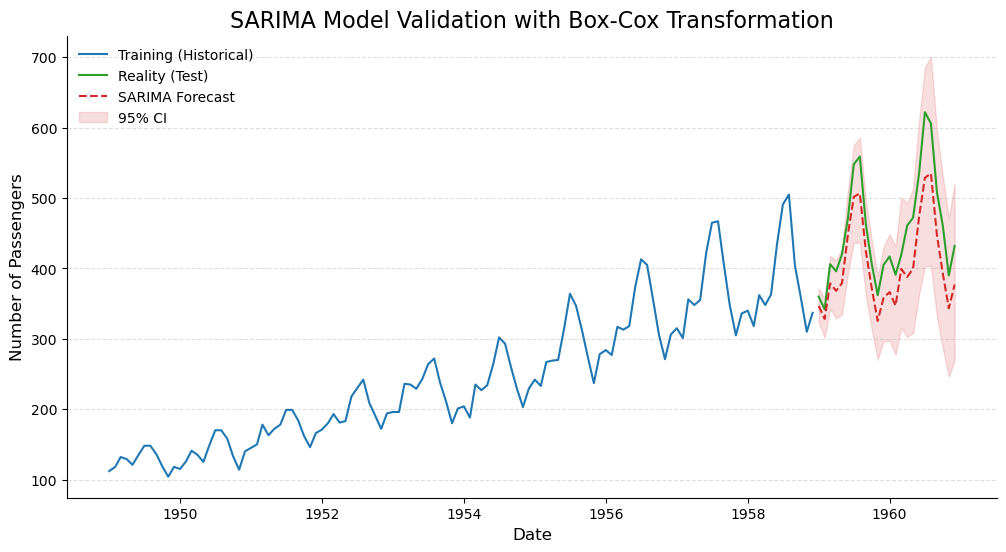

In [47]:
# ==========================================
# STEP 5: THE PLOT
# ==========================================

# Creating test period dates for the X-axis to align perfectly
datas_test = df['date'].iloc[-24:]

plt.figure(figsize=(12, 6))

# Plotting training history
plt.plot(df['date'][:-24], df['passengers'][:-24], label='Training (Historical)', color='#1f77b4')

# Plotting the real data that we "hid"
plt.plot(datas_test, real_test.values, label='Reality (Test)', color='#2ca02c')

# Plotting our forecast
plt.plot(datas_test, original_forecast.values, label='SARIMA Forecast', color='#d62728', linestyle='--')

# The shadow of the Confidence Interval
plt.fill_between(datas_test, lower_bound, upper_bound, color='#d62728', alpha=0.15, label='95% CI')

# --- GRAPH STYLING ---

# Sets the main title and increases the font size (16)
plt.title('SARIMA Model Validation with Box-Cox Transformation', fontsize=16)

# Sets the names of the X and Y axes
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Adds the legend to the top left corner and removes its 'box' (frame) to avoid clutter
plt.legend(loc='upper left', frameon=False)

# Adds only horizontal (y-axis) grid lines, dashed and very light (alpha=0.4)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Removes the top border line of the graph
plt.gca().spines['top'].set_visible(False)

# Removes the right border line of the graph (leaves the graph 'open' and modern)
plt.gca().spines['right'].set_visible(False)

plt.show()

# **Forecasting the Real Future**

In [48]:
Database = df['Pass_box'] #Passengers of all years

final_model = SARIMAX(Database,
                           order=(1, 1, 1),
                           seasonal_order=(1, 1, 1, 12))
production_model = final_model.fit(disp=False) # disp=False Hiding the large terminal output

# **Model Diagnostics: Statistical Validation of Residuals**

The following diagnostic plots are used to verify if the residuals behave as white noise. This step is essential to ensure that the model has captured all available information and that the forecasts are statistically sound.

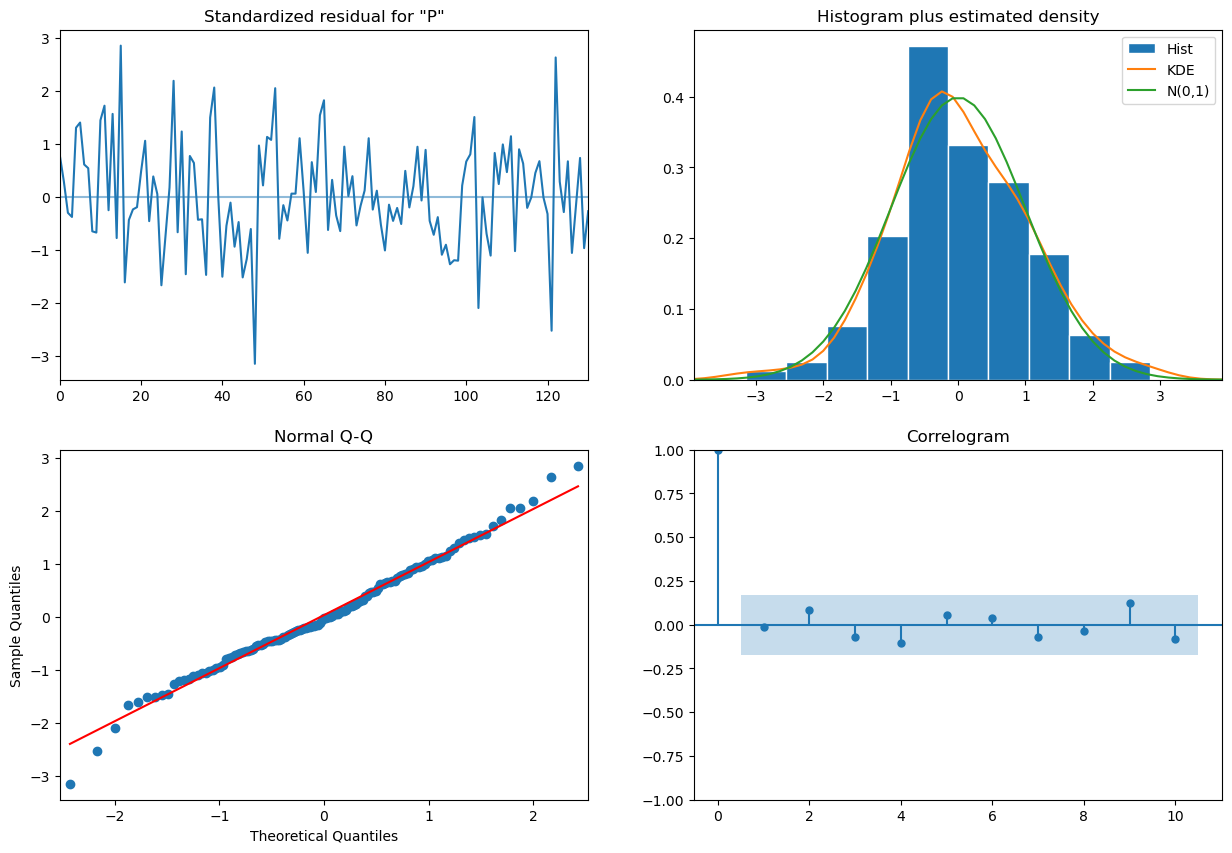

In [49]:
production_model.plot_diagnostics(figsize=(15, 10))
plt.show()

**Statistical Interpretation of Diagnostics:**

The diagnostic plots confirm that the model's residuals behave as **White Noise**, which is the ideal scenario for time series forecasting:

**Standardized Residuals:** The errors are randomly distributed around zero with constant variance, showing no remaining patterns or trends.

**Histogram & KDE:** The Kernel Density Estimate (KDE) closely aligns with the $N(0,1)$ normal distribution curve, indicating that the residuals are normally distributed.

**Normal Q-Q Plot:** Most points lie directly on the red reference line, further validating the assumption of normality.

**Correlogram (ACF):** All autocorrelation lags (except lag 0) remain within the shaded confidence interval. This proves there is no significant information left in the residuals that the model failed to capture.

# **Plotting**

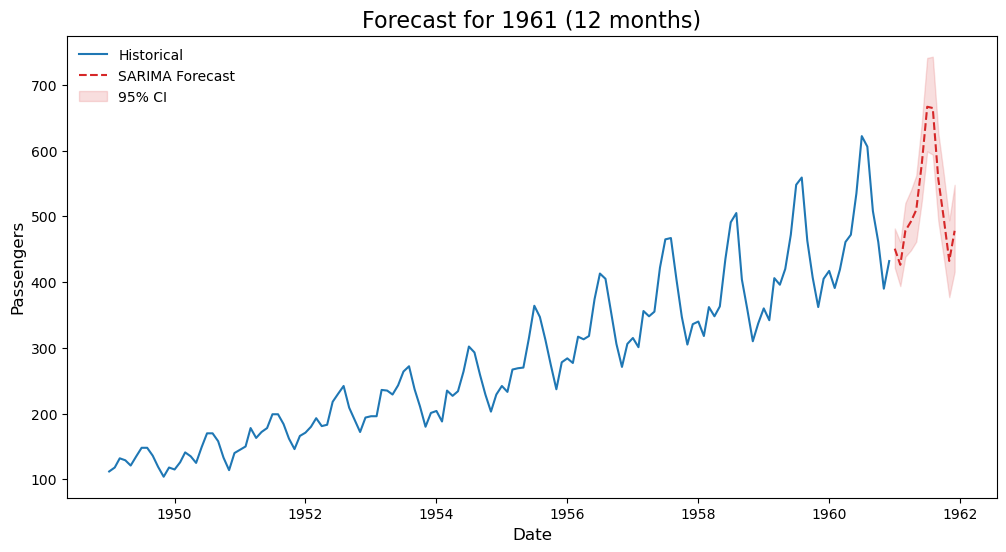

In [50]:
# Creating test period dates for the X-axis to align perfectly
start_date = df['date'].iloc[-1] + pd.DateOffset(months=1)
datas_fore = pd.date_range(start=start_date, periods=12, freq='MS')
dt = df['date'] # original data

# Generates the forecast for the next 12 months
final_forecast = production_model.get_forecast(steps=12)

# Extracts the mean forecast
forecast_box2 = final_forecast.predicted_mean

# Extracts the confidence interval
intervals_box2 = final_forecast.conf_int()

# Bringing forecasts and intervals back to the real world using the function
future_projection = inv_boxcox(forecast_box2, lam)
final_lower_bound = inv_boxcox(intervals_box2.iloc[:, 0], lam)
final_upper_bound = inv_boxcox(intervals_box2.iloc[:, 1], lam)

plt.figure(figsize=(12, 6))
plt.title(f'Forecast for {datas_fore[0].year} (12 months)', fontsize=16)
plt.plot(dt, df['passengers'], label='Historical')
plt.plot(datas_fore, future_projection.values, label='SARIMA Forecast', color='#d62728', linestyle='--' )

# Adding the shadow of the confidence interval
plt.fill_between(datas_fore, final_lower_bound, final_upper_bound, color='#d62728', alpha=0.15, label='95% CI')

# Axes and legend
plt.ylabel('Passengers', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', frameon=False)

plt.show()

# **Conclusion**





In summary, the SARIMA model demonstrated exceptional performance, achieving an **accuracy rate of approximately 90%** (with a 10% error margin). A critical factor in this success was the application of the **Box-Cox transformation**. By addressing the **heteroscedasticity** found in the original series and stabilizing the variance, we ensured that the final projections remained consistent and weren't misled by the data's volatility.

One of the most significant results is that the actual data points remained consistently within the **95% confidence intervals**. This validates the model's reliability for strategic decision-making, as it accurately captured the seasonal cycles and growth trends while keeping the uncertainty under control.

This project marks a major milestone in our time series analysis journey. However, the exploration doesn't stop here. As a next step, this analysis could be extended to **SARIMAX** to incorporate **exogenous variables**, or applied to real-world datasets such as energy demand or e-commerce sales.

